<a href="https://colab.research.google.com/github/Soljafree60/git-work/blob/main/02_Crank_Nicolson_FDM_Black_Scholes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 02 — Crank–Nicolson Finite Difference Method
## Black–Scholes European Call Option

We will implement and validates the Crank–Nicolson finite difference method for the Black–Scholes PDE.

Using time to maturity

$$
\tau=T-t,
$$

the PDE can be written as

$$
V_\tau
=
\frac12\sigma^2S^2V_{SS}
+
rSV_S
-
rV.
$$

The Crank–Nicolson method averages the spatial differential operator between two adjacent time levels, producing a tridiagonal linear system at each time step (Crank & Nicolson, 1947; Duffy, 2006).



## 1. Import numerical libraries


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from scipy.stats import norm
from scipy.linalg import solve_banded



### Why these libraries are used

NumPy is used to construct the asset-price and time grids and perform array operations (Harris et al., 2020). SciPy's `solve_banded` routine is used because the Crank–Nicolson discretisation produces a tridiagonal linear system, which has a banded matrix structure (Virtanen et al., 2020). Matplotlib is used for the convergence and error figures (Hunter, 2007), while pandas is used to organise the numerical results into tables.


## 2. Define the common Black–Scholes baseline parameters


In [ ]:

S0 = 100.0
K = 100.0
r = 0.05
sigma = 0.20
T = 1.0
S_max = 200.0

print("S0 =", S0)
print("K =", K)
print("r =", r)
print("sigma =", sigma)
print("T =", T)
print("S_max =", S_max)


S0 = 100.0
K = 100.0
r = 0.05
sigma = 0.2
T = 1.0
S_max = 200.0



### Why the same parameters are reused

The FDM must solve exactly the same financial problem as the analytical benchmark. Reusing the baseline parameters ensures that any difference between the two outputs is due to numerical approximation rather than different market conditions.

The parameters are standard Black–Scholes quantities (Black & Scholes, 1973; Hull, 2018).


## 3. Analytical benchmark used for FDM validation


In [ ]:

def black_scholes_call(S, K, r, sigma, T, t=0.0):
    scalar_input = np.isscalar(S)
    S = np.asarray(S, dtype=float)

    tau = T - t

    if tau <= 0:
        result = np.maximum(S - K, 0.0)
        return float(result) if scalar_input else result

    result = np.zeros_like(S, dtype=float)

    positive = S > 0
    S_pos = S[positive]

    d1 = (
        np.log(S_pos / K)
        + (r + 0.5 * sigma**2) * tau
    ) / (sigma * np.sqrt(tau))

    d2 = d1 - sigma * np.sqrt(tau)

    result[positive] = (
        S_pos * norm.cdf(d1)
        - K * np.exp(-r * tau) * norm.cdf(d2)
    )

    return float(result) if scalar_input else result


analytical_price = black_scholes_call(
    S0,
    K,
    r,
    sigma,
    T
)

print(f"Analytical Black-Scholes price: {analytical_price:.12f}")


Analytical Black-Scholes price: 10.450583572186



### Why I included the analytical solution again

I used the FDM experiment not only to generate a numerical price but to **validate** the finite-difference implementation. The exact Black–Scholes solution therefore acts as the ground truth for calculating price error and domain-wide error measures (Black & Scholes, 1973; Hull, 2018).


## 4. Implement the Crank–Nicolson solver


In [ ]:

def crank_nicolson_call(
    S_max,
    K,
    r,
    sigma,
    T,
    M,
    N
):
    """
    Crank-Nicolson solver for a European call option.

    N = number of asset-price intervals
    M = number of time-to-maturity steps
    """

    dS = S_max / N
    dt = T / M

    S = np.linspace(
        0.0,
        S_max,
        N + 1
    )

    # At tau = 0, the option is at maturity.
    V = np.maximum(
        S - K,
        0.0
    )

    i = np.arange(
        1,
        N
    )

    # Crank-Nicolson coefficients
    a = 0.25 * dt * (
        sigma**2 * i**2
        - r * i
    )

    b = -0.5 * dt * (
        sigma**2 * i**2
        + r
    )

    c = 0.25 * dt * (
        sigma**2 * i**2
        + r * i
    )

    # Banded representation of the left-hand matrix
    A = np.zeros(
        (3, N - 1)
    )

    A[0, 1:] = -c[:-1]
    A[1, :] = 1.0 - b
    A[2, :-1] = -a[1:]

    # Move forward in time-to-maturity tau
    for n in range(M):

        tau_new = (
            (n + 1) * dt
        )

        rhs = (
            a * V[:-2]
            + (1.0 + b) * V[1:-1]
            + c * V[2:]
        )

        # European call boundary conditions
        V_left_new = 0.0

        V_right_new = (
            S_max
            - K * np.exp(
                -r * tau_new
            )
        )

        # Contributions from the boundaries
        rhs[0] += (
            a[0] * V_left_new
        )

        rhs[-1] += (
            c[-1] * V_right_new
        )

        # Solve the tridiagonal system
        V_inner = solve_banded(
            (1, 1),
            A,
            rhs
        )

        V[0] = V_left_new
        V[1:-1] = V_inner
        V[-1] = V_right_new

    return S, V



### Why I used the Crank–Nicolson method

Crank–Nicolson is an implicit finite-difference method formed by averaging the differential operator between adjacent time levels. It is widely used for parabolic PDEs and financial engineering because it provides a strong balance between stability and accuracy (Crank & Nicolson, 1947; Duffy, 2006).

### Why I used time to maturity

The European call payoff is known at maturity. Defining

$$
\tau=T-t
$$

changes the terminal condition into an initial condition:

$$
V(S,0)=\max(S-K,0).
$$

The scheme can then step forward in $\tau$ from maturity toward the present. This avoids sign confusion when implementing a PDE that is naturally specified by a terminal payoff (Duffy, 2006).

### Why I used a banded solver

The finite-difference stencil couples each interior point only to its immediate neighbours. This produces a tridiagonal matrix. `solve_banded` exploits that structure rather than using a general dense matrix solve, which is computationally more efficient (Virtanen et al., 2020).

### Why I used these boundary conditions

For a European call,

$$
V(0,\tau)=0,
$$

and at a sufficiently large upper boundary,

$$
V(S_{\max},\tau)
=
S_{\max}
-
Ke^{-r\tau}.
$$

These are the standard Black–Scholes call boundaries used in the methodology (Duffy, 2006; Hull, 2018).


## 5. Run the baseline $100\times100$ FDM experiment


In [ ]:

N = 100
M = 100

start_time = time.perf_counter()

S_fdm, V_fdm = crank_nicolson_call(
    S_max=S_max,
    K=K,
    r=r,
    sigma=sigma,
    T=T,
    M=M,
    N=N
)

fdm_runtime = (
    time.perf_counter()
    - start_time
)

fdm_price = np.interp(
    S0,
    S_fdm,
    V_fdm
)

absolute_error = abs(
    fdm_price
    - analytical_price
)

print(f"FDM Call Price: {fdm_price:.12f}")
print(f"Analytical Call Price: {analytical_price:.12f}")
print(f"Absolute Error: {absolute_error:.12f}")
print(f"FDM Runtime: {fdm_runtime:.6f} seconds")


FDM Call Price: 10.440710244198
Analytical Call Price: 10.450583572186
Absolute Error: 0.009873327988
FDM Runtime: 0.010833 seconds



### Why I used the $100\times100$ grid as the baseline

The $100\times100$ grid provides a moderate numerical resolution that is computationally inexpensive while already producing a price close to the analytical benchmark. It is then complemented by a formal grid-refinement study rather than being assumed to be sufficiently accurate without evidence.

The absolute error at $S=100$ is reported because it gives an intuitive pointwise comparison with the analytical call price. However, the study also uses domain-wide errors because one point alone cannot establish the quality of the full numerical solution.


## 6. Calculate domain-wide FDM error measures


In [ ]:

V_exact_fdm_grid = black_scholes_call(
    S_fdm,
    K,
    r,
    sigma,
    T,
    t=0.0
)

fdm_error = (
    V_fdm
    - V_exact_fdm_grid
)

fdm_mse = np.mean(
    fdm_error**2
)

fdm_rmse = np.sqrt(
    fdm_mse
)

fdm_l2 = np.linalg.norm(
    fdm_error,
    ord=2
)

print(f"FDM MSE: {fdm_mse:.12e}")
print(f"FDM RMSE: {fdm_rmse:.12e}")
print(f"FDM L2 Error: {fdm_l2:.12e}")


FDM MSE: 1.314272945821e-05
FDM RMSE: 3.625290258477e-03
FDM L2 Error: 3.643371618815e-02



### Why I reported MSE, RMSE and $L_2$ error

The pointwise price at $S=100$ is important, but the FDM is intended to approximate the whole option-price curve. Domain-wide error metrics are therefore required.

- **MSE** measures the average squared discrepancy across the grid.
- **RMSE** expresses the average error magnitude in the same units as the option price.
- **$L_2$ error** measures the total magnitude of the error vector.

Using multiple error measures makes the validation less dependent on one asset-price location.


## 7. Plot analytical Black–Scholes vs Crank–Nicolson FDM


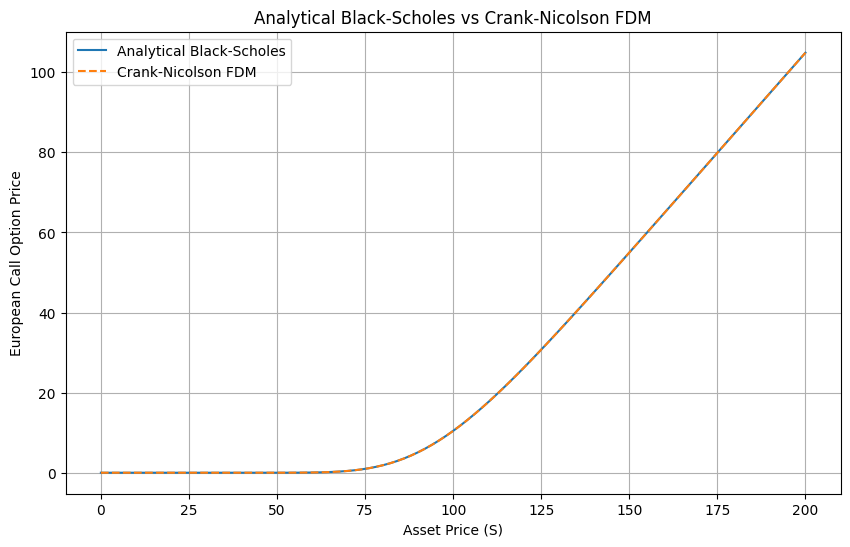

In [ ]:

plt.figure(figsize=(10, 6))

plt.plot(
    S_fdm,
    V_exact_fdm_grid,
    label="Analytical Black-Scholes"
)

plt.plot(
    S_fdm,
    V_fdm,
    "--",
    label="Crank-Nicolson FDM"
)

plt.xlabel("Asset Price (S)")
plt.ylabel("European Call Option Price")
plt.title("Analytical Black-Scholes vs Crank-Nicolson FDM")
plt.legend()
plt.grid(True)

plt.show()



### Why I plotted the analytical and numerical curves together

Two curves that overlap closely provide an immediate visual check that the numerical method captures the shape of the analytical solution. The figure complements, rather than replaces, the numerical error measures.

Matplotlib is used for visualisation (Hunter, 2007).



## 8. Plot the FDM error curve


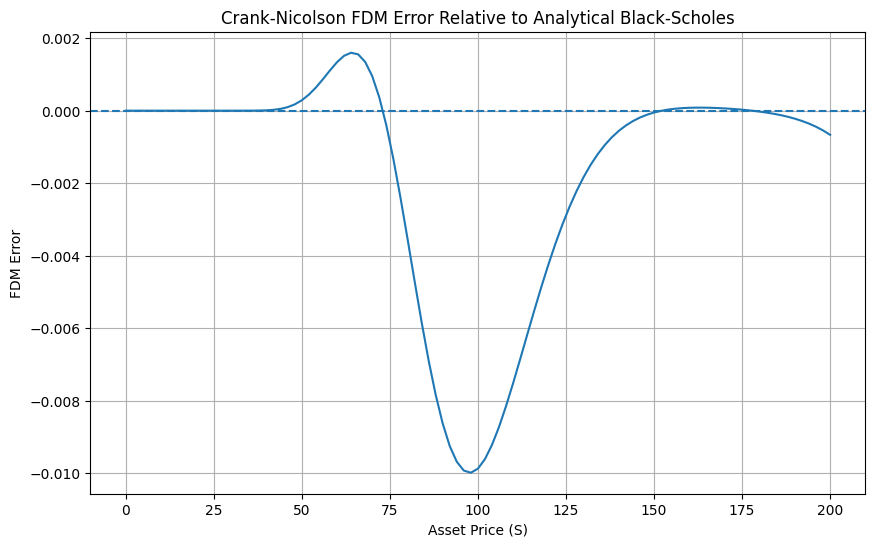

In [ ]:

plt.figure(figsize=(10, 6))

plt.plot(
    S_fdm,
    fdm_error
)

plt.axhline(
    0.0,
    linestyle="--"
)

plt.xlabel("Asset Price (S)")
plt.ylabel("FDM Error")
plt.title("Crank-Nicolson FDM Error Relative to Analytical Black-Scholes")
plt.grid(True)

plt.show()



### Why I showed the error curve separately

The analytical and FDM price curves can appear almost identical even when small numerical deviations remain. Plotting the error directly makes the location and direction of those deviations visible.

This is useful when assessing whether the approximation error is concentrated near the strike, the boundaries or other parts of the domain.


## 9. Perform the FDM grid-convergence study


In [ ]:

grid_sizes = [
    50,
    100,
    200,
    400
]

results = []

for N in grid_sizes:

    M = N

    start = time.perf_counter()

    S_grid_fdm, V_grid_fdm = crank_nicolson_call(
        S_max=S_max,
        K=K,
        r=r,
        sigma=sigma,
        T=T,
        M=M,
        N=N
    )

    runtime = (
        time.perf_counter()
        - start
    )

    V_exact_grid = black_scholes_call(
        S_grid_fdm,
        K,
        r,
        sigma,
        T,
        t=0.0
    )

    error = (
        V_grid_fdm
        - V_exact_grid
    )

    mse = np.mean(
        error**2
    )

    rmse = np.sqrt(
        mse
    )

    l2 = np.linalg.norm(
        error,
        ord=2
    )

    price = np.interp(
        S0,
        S_grid_fdm,
        V_grid_fdm
    )

    price_error = abs(
        price
        - analytical_price
    )

    results.append({
        "Grid": f"{N} x {M}",
        "N": N,
        "FDM Price": price,
        "Analytical Price": analytical_price,
        "Absolute Price Error": price_error,
        "MSE": mse,
        "RMSE": rmse,
        "L2 Error": l2,
        "Runtime (s)": runtime
    })


results_df = pd.DataFrame(
    results
)

results_df


,Grid,N,FDM Price,Analytical Price,Absolute Price Error,MSE,RMSE,L2 Error,Runtime (s)
0,50 x 50,50,10.410869,10.450584,0.039715,2.090416e-04,0.014458,0.103253,0.002083
1,100 x 100,100,10.440710,10.450584,0.009873,1.314273e-05,0.003625,0.036434,0.003523
2,200 x 200,200,10.448119,10.450584,0.002465,8.356656e-07,0.000914,0.012960,0.012706
3,400 x 400,400,10.449968,10.450584,0.000616,6.320102e-08,0.000251,0.005034,0.017033



### Why I carried out a grid-convergence study

A numerical PDE solution should not be accepted merely because one grid produces a plausible-looking price. The grid must be refined to test whether the solution approaches the known analytical benchmark as the discretisation becomes finer (Duffy, 2006).

The study uses

$$
50\times50,\quad
100\times100,\quad
200\times200,\quad
400\times400.
$$

Doubling both spatial and time resolution provides a simple and transparent refinement sequence.

The results obtained in the project showed the pointwise absolute error decreasing from approximately

$$
0.03971
$$

to

$$
0.00987,\quad
0.00246,\quad
0.000616,
$$

which is consistent with approximately second-order convergence in this experiment (Crank & Nicolson, 1947; Duffy, 2006).



## 10. Plot convergence and runtime


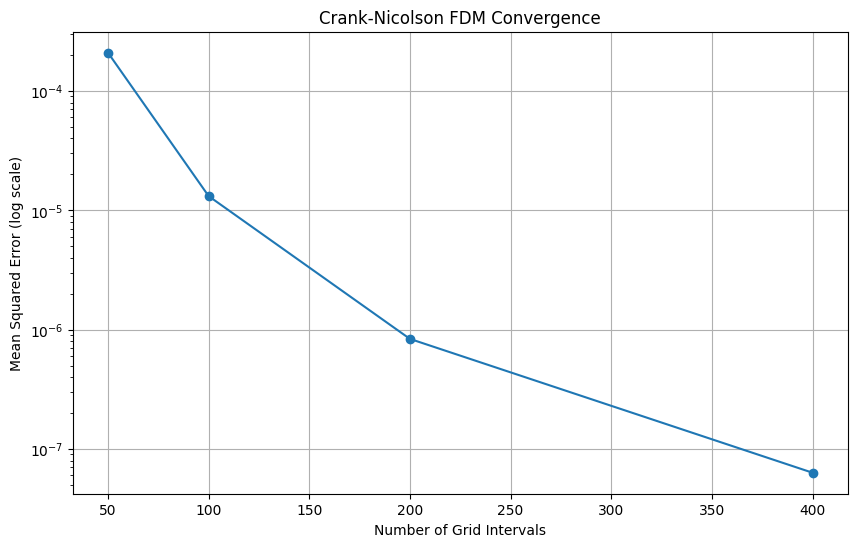

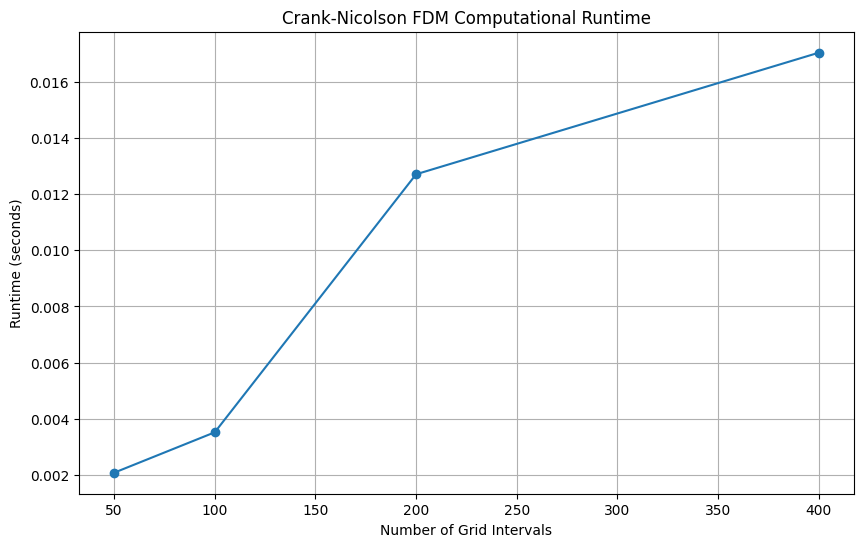

In [ ]:

plt.figure(figsize=(10, 6))

plt.plot(
    results_df["N"],
    results_df["MSE"],
    marker="o"
)

plt.yscale("log")
plt.xlabel("Number of Grid Intervals")
plt.ylabel("Mean Squared Error (log scale)")
plt.title("Crank-Nicolson FDM Convergence")
plt.grid(True)

plt.show()


plt.figure(figsize=(10, 6))

plt.plot(
    results_df["N"],
    results_df["Runtime (s)"],
    marker="o"
)

plt.xlabel("Number of Grid Intervals")
plt.ylabel("Runtime (seconds)")
plt.title("Crank-Nicolson FDM Computational Runtime")
plt.grid(True)

plt.show()



### Why I plotted both accuracy and runtime

Grid refinement normally improves numerical accuracy but increases computational work. The two figures therefore show the trade-off between **accuracy** and **computational cost**.

The convergence plot uses a logarithmic error scale because the MSE changes by several orders of magnitude. The runtime plot shows the additional computation required as the grid becomes finer. This supports the later comparison with PINN computational efficiency.




## 11. Results summary

For the $100\times100$ baseline grid, the project obtained approximately

$$
V_{\mathrm{FDM}}(100,0)
=
10.44071024,
$$

compared with

$$
V_{\mathrm{BS}}(100,0)
=
10.45058357.
$$

The absolute pricing error was therefore approximately

$$
0.00987333.
$$

The grid-convergence study showed:

$$
\begin{aligned}
N=50  &: \quad 0.03971,\\
N=100 &: \quad 0.00987,\\
N=200 &: \quad 0.00246,\\
N=400 &: \quad 0.000616.
\end{aligned}
$$

The reduction in pointwise error as the grid is refined supports the validity of the Crank–Nicolson implementation and establishes FDM as a reliable benchmark for comparison with the PINN.





## References

Black, F. & Scholes, M. 1973. The pricing of options and corporate liabilities. *Journal of Political Economy*, 81(3):637-654. DOI: 10.1086/260062.

Crank, J. & Nicolson, P. 1947. A practical method for numerical evaluation of solutions of partial differential equations of the heat-conduction type. *Proceedings of the Cambridge Philosophical Society*, 43(1):50-67. DOI: 10.1017/S0305004100023197.

Duffy, D.J. 2006. *Finite difference methods in financial engineering: A partial differential equation approach*. Chichester: John Wiley & Sons. DOI: 10.1002/9781118673447.

Harris, C.R., Millman, K.J., van der Walt, S.J., Gommers, R., Virtanen, P., Cournapeau, D., Wieser, E., Taylor, J., Berg, S., Smith, N.J., Kern, R., Picus, M., Hoyer, S., van Kerkwijk, M.H., Brett, M., Haldane, A., del Río, J.F., Wiebe, M., Peterson, P., Gérard-Marchant, P., Sheppard, K., Reddy, T., Weckesser, W., Abbasi, H., Gohlke, C. & Oliphant, T.E. 2020. Array programming with NumPy. *Nature*, 585:357-362. DOI: 10.1038/s41586-020-2649-2.

Hull, J.C. 2018. *Options, futures, and other derivatives*. 10th ed. Harlow: Pearson.

Hunter, J.D. 2007. Matplotlib: A 2D graphics environment. *Computing in Science & Engineering*, 9(3):90-95. DOI: 10.1109/MCSE.2007.55.

Virtanen, P., Gommers, R., Oliphant, T.E., Haberland, M., Reddy, T., Cournapeau, D., Burovski, E., Peterson, P., Weckesser, W., Bright, J., van der Walt, S.J., Brett, M., Wilson, J., Millman, K.J., Mayorov, N., Nelson, A.R.J., Jones, E., Kern, R., Larson, E., Carey, C.J., Polat, İ., Feng, Y., Moore, E.W., VanderPlas, J., Laxalde, D., Perktold, J., Cimrman, R., Henriksen, I., Quintero, E.A., Harris, C.R., Archibald, A.M., Ribeiro, A.H., Pedregosa, F., van Mulbregt, P. & SciPy 1.0 Contributors. 2020. SciPy 1.0: Fundamental algorithms for scientific computing in Python. *Nature Methods*, 17:261-272. DOI: 10.1038/s41592-019-0686-2.

